In [ ]:
# Alpha Analysis - Partial Results

This notebook analyzes partial results from the alpha analysis grid search, replicating the functionality from `partial_analysis.py`.


In [4]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import dataclasses
from fleetmix.config import load_fleetmix_params
import math

# Set up paths and directories
BASE_CONFIG_PATH = Path("../../src/fleetmix/config/default_config.yaml")
RESULTS_RAW = Path("../../results_raw_v3")
FIGS_DIR = Path("../../results/partial_figs_v3")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base config path: {BASE_CONFIG_PATH}")
print(f"Results directory: {RESULTS_RAW}")
print(f"Figures directory: {FIGS_DIR}")
print(f"Results directory exists: {RESULTS_RAW.exists()}")
print(f"Config file exists: {BASE_CONFIG_PATH.exists()}")


Base config path: ../../src/fleetmix/config/default_config.yaml
Results directory: ../../results_raw_v3
Figures directory: ../../results/partial_figs_v3
Results directory exists: True
Config file exists: True


In [3]:
# Helper function for formatting basis points
def _bp(value: float) -> str:
    """Format a ratio (1 = 100%) as basis points string."""
    return f"{value * 10000:.0f} bp"


In [7]:
def load_partial_results():
    """Load all existing JSON results."""
    all_results = []
    json_files = list(RESULTS_RAW.glob("sales_*_demand_*.json"))
    
    print(f"Found {len(json_files)} result files")
    
    for json_path in json_files:
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)
                all_results.append(data)
        except json.JSONDecodeError:
            print(f"Skipping corrupted file: {json_path}")
            continue
    
    df = pd.DataFrame(all_results)
    print(f"Loaded {len(df)} results")
    if len(df) > 0:
        print(f"Fleet types: {df['fleet_type'].value_counts().to_dict()}")
        print(
            f"Alpha range: {df['alpha'].min():.2f} – {df['alpha'].max():.2f}  | "
            f"Surcharge: {df['alpha_surcharge_pct'].min():.0f}% – {df['alpha_surcharge_pct'].max():.0f}%"
        )
        print(
            f"C range: {df['C'].min():.0f} – {df['C'].max():.0f}  | "
            f"C as % of SCV: {df['c_pct_scv'].min():.0f}% – {df['c_pct_scv'].max():.0f}%"
        )
        print(f"Unique days: {df['day_id'].nunique()}")
    
    # Load base parameters once to obtain SCV fixed cost
    base_params = load_fleetmix_params(BASE_CONFIG_PATH)
    base_vehicle_spec = next(iter(base_params.problem.vehicles.values()))
    f_sc = float(base_vehicle_spec.fixed_cost)
    
    print(f"Using SCV fixed cost f_SC = {f_sc}")
    
    # Compute unit-free expressions (vectorised, no branching)
    df['alpha_surcharge_pct'] = 100 * (df['alpha'] - 1)
    df['c_pct_scv'] = 100 * df['C'] / f_sc
    
    # Filter SCV data for baseline calculations
    scv_df = df[df['fleet_type'] == 'SCV']
    
    if len(scv_df) > 0:
        scv_mean_cost = scv_df['solver_cost'].mean()
        scv_mean_kg = scv_df['cost_per_kg'].mean()
        scv_mean_drop = scv_df['cost_per_drop'].mean()
        
        df['cost_index'] = df['solver_cost'] / scv_mean_cost
        df['cost_per_kg_index'] = df['cost_per_kg'] / scv_mean_kg
        df['cost_per_drop_index'] = df['cost_per_drop'] / scv_mean_drop
    
    return df

# Load the data
df = load_partial_results()


Found 3204 result files
Loaded 3204 results
Fleet types: {'MCV': 3168, 'SCV': 36}
Alpha range: 1.00 – 2.00  | Surcharge: 0% – 100%
C range: 0 – 70  | C as % of SCV: 0% – 70%
Unique days: 36
Using SCV fixed cost f_SC = 100.0


In [ ]:
## Summary Statistics


In [16]:
def summary_stats(df):
    """Print summary statistics."""
    print("="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    print(f"\nOverall dataset:")
    print(f"  Total results: {len(df)}")
    print(f"  Fleet types: {df['fleet_type'].value_counts().to_dict()}")
    print(f"  Unique days: {df['day_id'].nunique()}")
    
    if len(df[df['fleet_type'] == 'MCV']) > 0:
        mcv_df = df[df['fleet_type'] == 'MCV']
        print(f"\nMCV parameter ranges:")
        print(f"  Alpha: {mcv_df['alpha'].min():.2f} - {mcv_df['alpha'].max():.2f}")
        print(f"  C: {mcv_df['C'].min():.0f} - {mcv_df['C'].max():.0f}")
        print(f"  Unique (alpha, C) combinations: {mcv_df[['alpha', 'C']].drop_duplicates().shape[0]}")
    
    print(f"\nCost statistics by fleet type:")
    cost_stats = df.groupby('fleet_type')[['solver_cost', 'cost_per_kg', 'cost_per_drop']].agg(['mean', 'std', 'min', 'max'])
    print(cost_stats)
    
    if 'cost_index' in df.columns:
        idx_stats = df.groupby('fleet_type')[['cost_index', 'cost_per_kg_index', 'cost_per_drop_index']].mean()
        print("\nAverage cost indices (basis points):")
        for ft, row in idx_stats.iterrows():
            print(
                f"  {ft}: total {_bp(row['cost_index'])}, per-kg {_bp(row['cost_per_kg_index'])}, per-drop {_bp(row['cost_per_drop_index'])}"
            )
 
    # Find best performing configurations
    if len(df[df['fleet_type'] == 'MCV']) > 0 and len(df[df['fleet_type'] == 'SCV']) > 0:
        print(f"\nBest MCV configurations (lowest cost per kg):")
        best_mcv = df[df['fleet_type'] == 'MCV'].nsmallest(5, 'cost_per_kg')[
            ['day_id', 'alpha', 'C', 'cost_per_kg', 'solver_cost', 'alpha_surcharge_pct', 'c_pct_scv', 'cost_per_kg_index']
        ]
        for _, row in best_mcv.iterrows():
            print(
                f"Day {row['day_id']}: α={row['alpha']:.2f} ({row['alpha_surcharge_pct']:.0f}% surcharge), "
                f"C={row['C']:.0f} ({row['c_pct_scv']:.1f}% of SCV), "
                f"cost/kg={row['cost_per_kg']:.3f} ({_bp(row['cost_per_kg_index'])})"
            )
        
        print(f"\nSCV baseline (cost per kg):")
        scv_stats = df[df['fleet_type'] == 'SCV'][['cost_per_kg', 'solver_cost']].agg(['mean', 'std'])
        print(scv_stats)

# Display summary statistics
if len(df) > 0:
    summary_stats(df)
else:
    print("No valid results found!")


SUMMARY STATISTICS

Overall dataset:
  Total results: 3204
  Fleet types: {'MCV': 3168, 'SCV': 36}
  Unique days: 36

MCV parameter ranges:
  Alpha: 1.00 - 2.00
  C: 0 - 70
  Unique (alpha, C) combinations: 88

Cost statistics by fleet type:
            solver_cost                                        cost_per_kg  \
                   mean          std          min          max        mean   
fleet_type                                                                   
MCV         5113.083690  1536.529953  1932.921686  11816.14335    0.200736   
SCV         4759.562642  1125.618546  3008.558958   8159.82356    0.187389   

                                         cost_per_drop                       \
                 std       min       max          mean       std        min   
fleet_type                                                                    
MCV         0.044051  0.083610  0.344137     19.724032  3.697684  11.111365   
SCV         0.026179  0.129098  0.244289     18.370

In [ ]:
## Cost Trends Analysis


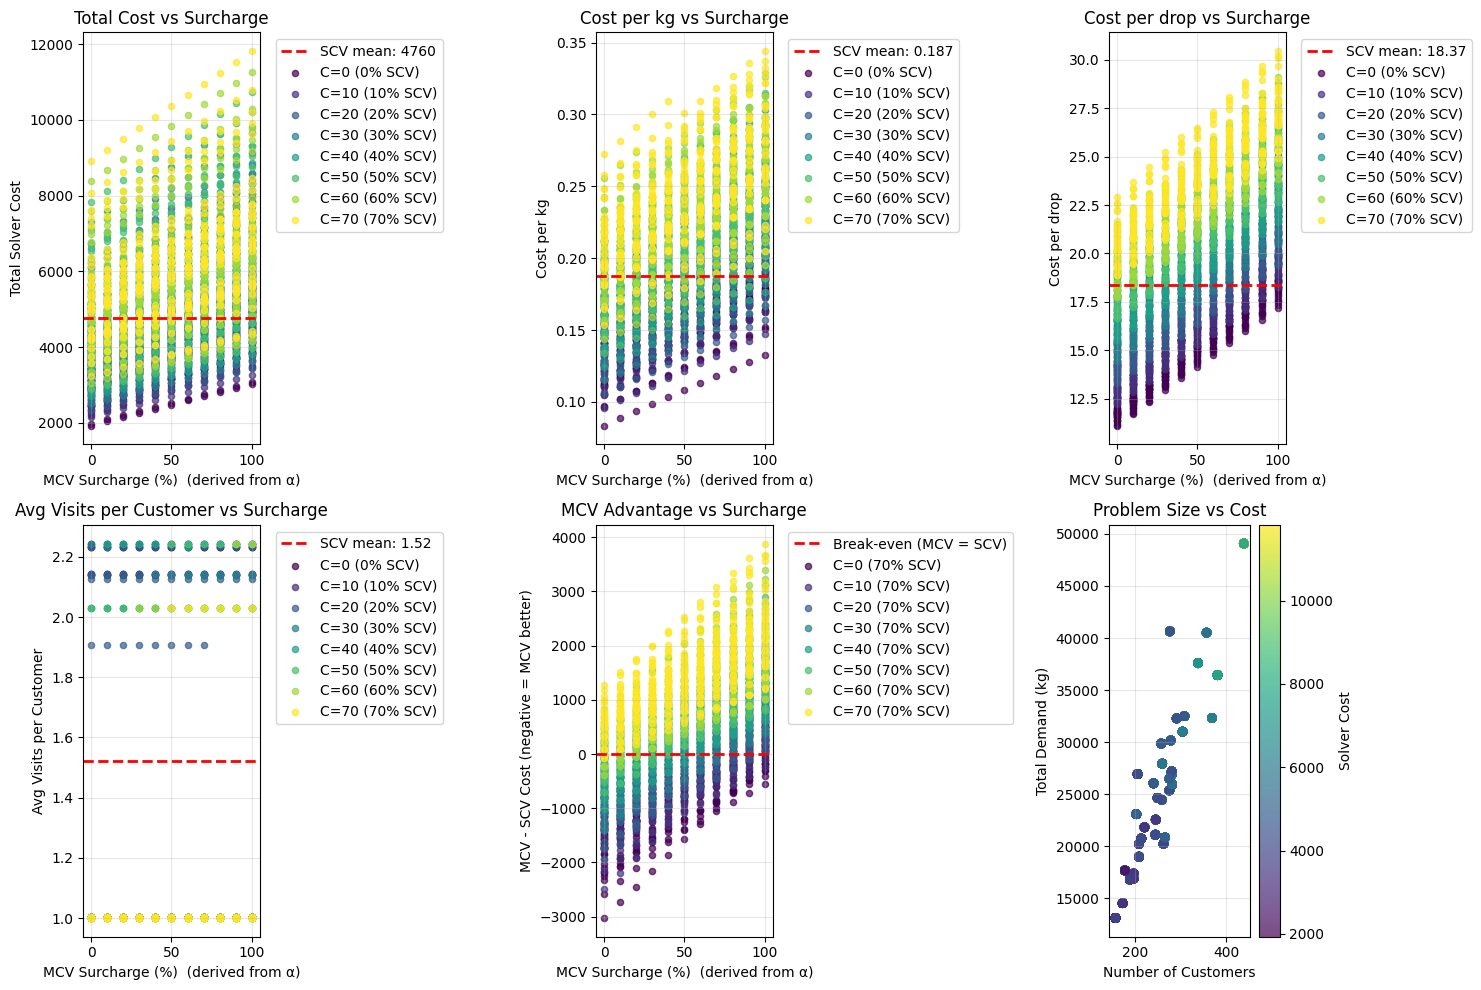

In [24]:
def plot_cost_trends(df):
    """Plot cost trends vs alpha."""
    plt.figure(figsize=(15, 10))
    
    mcv_df = df[df['fleet_type'] == 'MCV']
    scv_df = df[df['fleet_type'] == 'SCV']
    
    # Subplot 1: Raw costs
    plt.subplot(2, 3, 1)
    if len(scv_df) > 0:
        scv_mean = scv_df['solver_cost'].mean()
        plt.axhline(scv_mean, color='red', linestyle='--', linewidth=2, 
                   label=f'SCV mean: {scv_mean:.0f}')
    
    # Show different C values with different colors
    c_values = sorted(mcv_df['C'].unique())[:8]  # Show up to 8 C values
    colors = plt.cm.viridis(np.linspace(0, 1, len(c_values)))
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['solver_cost'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Total Solver Cost')
    plt.title('Total Cost vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Cost per kg
    plt.subplot(2, 3, 2)
    if len(scv_df) > 0:
        scv_mean_kg = scv_df['cost_per_kg'].mean()
        plt.axhline(scv_mean_kg, color='red', linestyle='--', linewidth=2,
                   label=f'SCV mean: {scv_mean_kg:.3f}')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['cost_per_kg'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Cost per kg')
    plt.title('Cost per kg vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Cost per drop
    plt.subplot(2, 3, 3)
    if len(scv_df) > 0:
        scv_mean_drop = scv_df['cost_per_drop'].mean()
        plt.axhline(scv_mean_drop, color='red', linestyle='--', linewidth=2,
                   label=f'SCV mean: {scv_mean_drop:.2f}')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['cost_per_drop'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Cost per drop')
    plt.title('Cost per drop vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 4: Average visits per customer (replacing split rate)
    plt.subplot(2, 3, 4)
    # Add SCV horizontal line for comparison
    if len(scv_df) > 0:
        scv_mean_visits = scv_df['avg_visits_per_customer'].mean()
        plt.axhline(scv_mean_visits, color='red', linestyle='--', linewidth=2,
                   label=f'SCV mean: {scv_mean_visits:.2f}')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['avg_visits_per_customer'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Avg Visits per Customer')
    plt.title('Avg Visits per Customer vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 5: MCV advantage (cost difference from SCV)
    plt.subplot(2, 3, 5)
    if len(scv_df) > 0:
        plt.axhline(0, color='red', linestyle='--', linewidth=2,
                   label='Break-even (MCV = SCV)')
        
        for c_val, color in zip(c_values, colors):
            c_data = mcv_df[mcv_df['C'] == c_val]
            if len(c_data) > 1:
                # Calculate advantage: negative means MCV is better
                advantage = []
                surcharges = []
                for _, row in c_data.iterrows():
                    day_scv = scv_df[scv_df['day_id'] == row['day_id']]
                    if len(day_scv) > 0:
                        scv_cost = day_scv['solver_cost'].iloc[0]
                        advantage.append(row['solver_cost'] - scv_cost)
                        surcharges.append(row['alpha_surcharge_pct'])
                
                if len(advantage) > 0:
                    plt.scatter(surcharges, advantage, alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', 
                               color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('MCV - SCV Cost (negative = MCV better)')
    plt.title('MCV Advantage vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 6: Number of customers vs demand
    plt.subplot(2, 3, 6)
    plt.scatter(df['num_customers'], df['total_demand_kg'], 
               c=df['solver_cost'], alpha=0.7, cmap='viridis')
    plt.colorbar(label='Solver Cost')
    plt.xlabel('Number of Customers')
    plt.ylabel('Total Demand (kg)')
    plt.title('Problem Size vs Cost')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'partial_cost_trends_reexpressed.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate cost trends plot
if len(df) > 0:
    plot_cost_trends(df)


In [ ]:
## Cost Index Trends


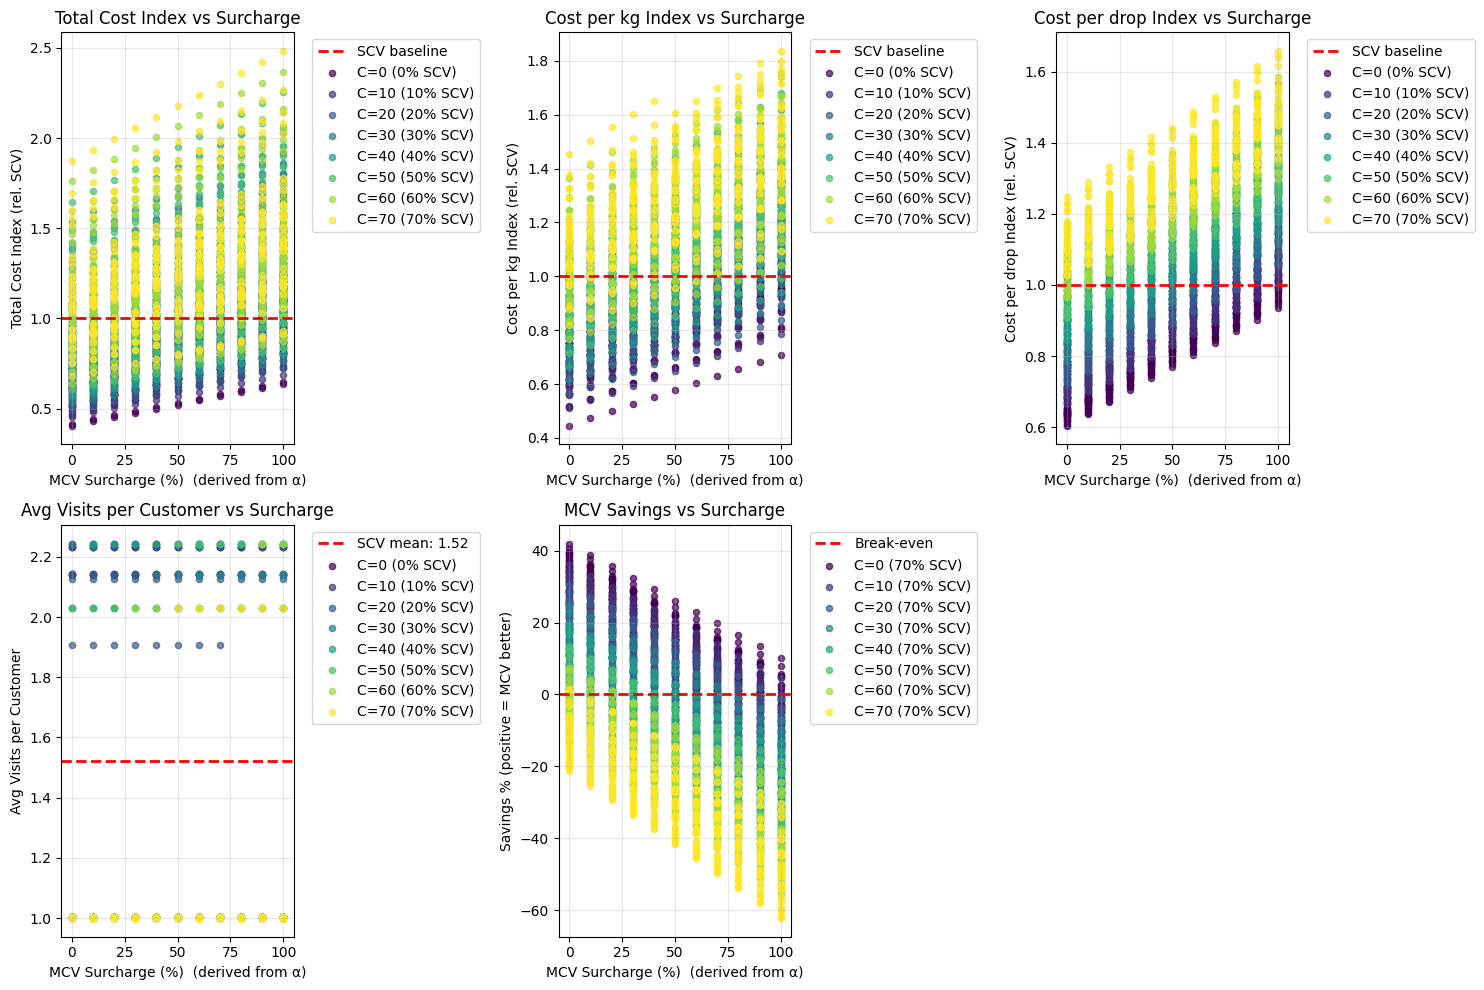

In [25]:
def plot_index_trends(df):
    """Plot cost index trends vs surcharge."""
    plt.figure(figsize=(15, 10))
    
    mcv_df = df[df['fleet_type'] == 'MCV']
    scv_df = df[df['fleet_type'] == 'SCV']
    
    # Subplot 1: Cost index
    plt.subplot(2, 3, 1)
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, 
                label='SCV baseline')
    
    c_values = sorted(mcv_df['C'].unique())[:8]
    colors = plt.cm.viridis(np.linspace(0, 1, len(c_values)))
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['cost_index'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Total Cost Index (rel. SCV)')
    plt.title('Total Cost Index vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Cost per kg index
    plt.subplot(2, 3, 2)
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, 
                label='SCV baseline')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['cost_per_kg_index'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Cost per kg Index (rel. SCV)')
    plt.title('Cost per kg Index vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Cost per drop index
    plt.subplot(2, 3, 3)
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, 
                label='SCV baseline')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['cost_per_drop_index'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Cost per drop Index (rel. SCV)')
    plt.title('Cost per drop Index vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 4: Avg visits (same as in cost trends, but using surcharge)
    plt.subplot(2, 3, 4)
    if len(scv_df) > 0:
        scv_mean_visits = scv_df['avg_visits_per_customer'].mean()
        plt.axhline(scv_mean_visits, color='red', linestyle='--', linewidth=2,
                    label=f'SCV mean: {scv_mean_visits:.2f}')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            pct = c_data['c_pct_scv'].iloc[0]
            plt.scatter(c_data['alpha_surcharge_pct'], c_data['avg_visits_per_customer'], 
                       alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Avg Visits per Customer')
    plt.title('Avg Visits per Customer vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Subplot 5: Savings % (negative advantage as %)
    plt.subplot(2, 3, 5)
    plt.axhline(0, color='red', linestyle='--', linewidth=2,
                label='Break-even')
    
    for c_val, color in zip(c_values, colors):
        c_data = mcv_df[mcv_df['C'] == c_val]
        if len(c_data) > 1:
            savings_pct = []
            surcharges = []
            for _, row in c_data.iterrows():
                day_scv = scv_df[scv_df['day_id'] == row['day_id']]
                if len(day_scv) > 0:
                    scv_cost = day_scv['solver_cost'].iloc[0]
                    savings = (scv_cost - row['solver_cost']) / scv_cost * 100
                    savings_pct.append(savings)
                    surcharges.append(row['alpha_surcharge_pct'])
            
            if len(savings_pct) > 0:
                plt.scatter(surcharges, savings_pct, alpha=0.7, label=f'C={c_val:.0f} ({pct:.0f}% SCV)', 
                            color=color, s=20)
    
    plt.xlabel('MCV Surcharge (%)  (derived from α)')
    plt.ylabel('Savings % (positive = MCV better)')
    plt.title('MCV Savings vs Surcharge')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'partial_index_trends.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate index trends plot
if len(df) > 0 and 'cost_index' in df.columns:
    plot_index_trends(df)


In [ ]:
## Fleet Comparison


/var/folders/25/4v7xr45d0mv199l2rpp3c5x80000gp/T/ipykernel_30540/3648242034.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)
/var/folders/25/4v7xr45d0mv199l2rpp3c5x80000gp/T/ipykernel_30540/3648242034.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)
/var/folders/25/4v7xr45d0mv199l2rpp3c5x80000gp/T/ipykernel_30540/3648242034.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


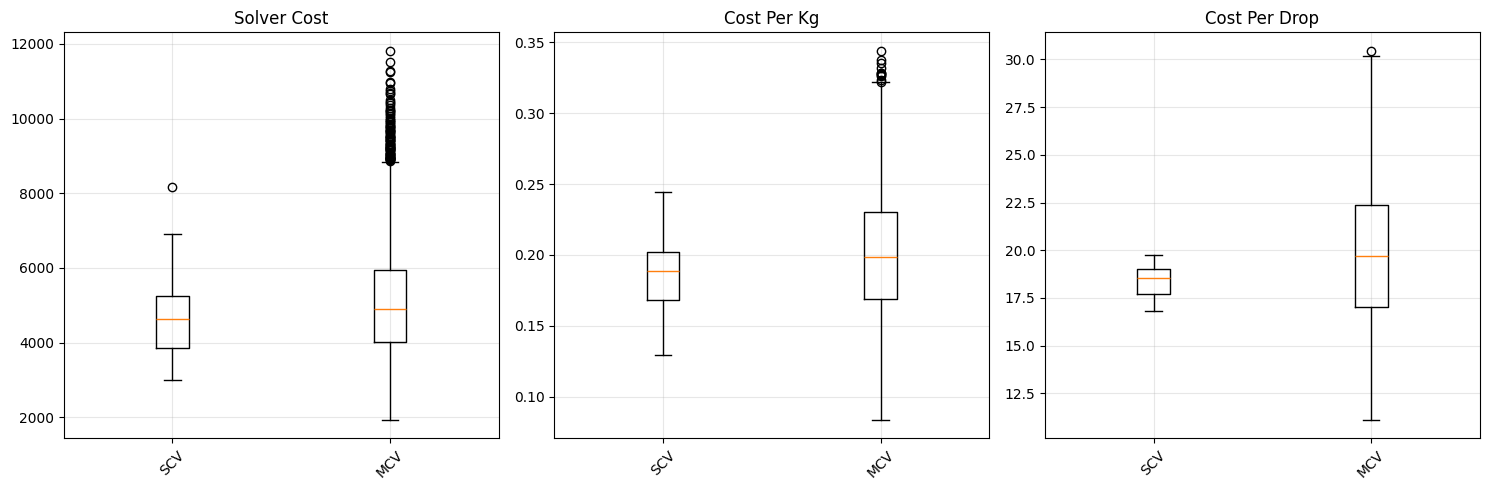

In [26]:
def plot_fleet_comparison(df):
    """Compare MCV vs SCV performance."""
    plt.figure(figsize=(15, 5))
    
    metrics = ['solver_cost', 'cost_per_kg', 'cost_per_drop']
    
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        
        # Create separate boxplots for each fleet type
        data_to_plot = []
        labels = []
        
        if len(df[df['fleet_type'] == 'SCV']) > 0:
            data_to_plot.append(df[df['fleet_type'] == 'SCV'][metric])
            labels.append('SCV')
        
        if len(df[df['fleet_type'] == 'MCV']) > 0:
            data_to_plot.append(df[df['fleet_type'] == 'MCV'][metric])
            labels.append('MCV')
        
        if data_to_plot:
            plt.boxplot(data_to_plot, labels=labels)
            plt.title(f'{metric.replace("_", " ").title()}')
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'partial_fleet_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate fleet comparison plot
if len(df) > 0:
    plot_fleet_comparison(df)


In [ ]:
## Coverage Analysis


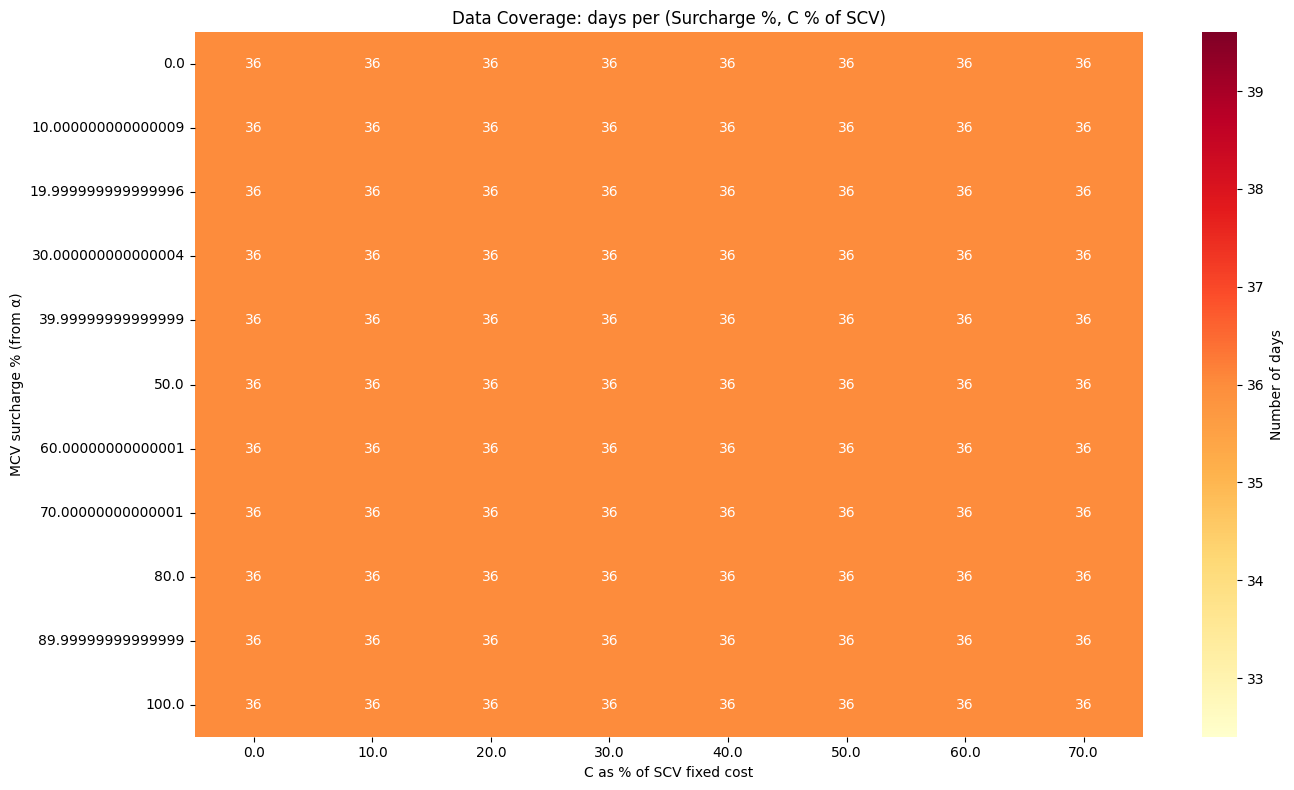

In [27]:
def coverage_analysis(df):
    """Heat-map of observed (α surcharge, C %) coverage."""
    mcv_df = df[df['fleet_type'] == 'MCV']

    if len(mcv_df) == 0:
        print("No MCV data found for coverage analysis")
        return

    rows_label = 'alpha_surcharge_pct'
    cols_label = 'c_pct_scv'
    alpha_vals = sorted(mcv_df[rows_label].unique())
    c_vals = sorted(mcv_df[cols_label].unique())
    coverage = mcv_df.groupby([rows_label, cols_label]).size().unstack(fill_value=0)
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        coverage.reindex(index=alpha_vals, columns=c_vals),
        annot=True,
        fmt='d',
        cmap='YlOrRd',
        cbar_kws={'label': 'Number of days'}
    )
    plt.title('Data Coverage: days per (Surcharge %, C % of SCV)')
    plt.xlabel('C as % of SCV fixed cost')
    plt.ylabel('MCV surcharge % (from α)')
    plt.tight_layout()
    plt.savefig(FIGS_DIR / 'partial_coverage_pct.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate coverage analysis
if len(df) > 0:
    coverage_analysis(df)


In [ ]:
## Save Results


In [28]:
# Save partial summary to file
if len(df) > 0:
    summary_path = Path("../../results/partial_summary.parquet")
    summary_path.parent.mkdir(exist_ok=True)
    df.to_parquet(summary_path)
    print(f"Saved partial summary to {summary_path}")
    print(f"Figures saved to {FIGS_DIR}/")
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)
else:
    print("No data to save.")


Saved partial summary to ../../results/partial_summary.parquet
Figures saved to ../../results/partial_figs_v3/

ANALYSIS COMPLETE


In [ ]:
## Data Exploration (Optional)

The following cells provide additional exploration of the loaded data.


In [29]:
# Display basic info about the dataframe
if len(df) > 0:
    print("DataFrame Info:")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\nFirst few rows:")
    df.head()


DataFrame Info:
Shape: (3204, 16)
Columns: ['day_id', 'num_customers', 'total_demand_kg', 'solver_cost', 'fleet_type', 'alpha', 'C', 'cost_per_drop', 'cost_per_kg', 'split_rate', 'avg_visits_per_customer', 'alpha_surcharge_pct', 'c_pct_scv', 'cost_index', 'cost_per_kg_index', 'cost_per_drop_index']

First few rows:


In [30]:
# Display summary statistics for key metrics
if len(df) > 0:
    print("Summary statistics for key metrics:")
    key_metrics = ['solver_cost', 'cost_per_kg', 'cost_per_drop', 'alpha', 'C']
    available_metrics = [col for col in key_metrics if col in df.columns]
    df[available_metrics].describe()


Summary statistics for key metrics:
